In [16]:
import os

from physics.simulation import msq
from rolypoly import dataset, model

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import hist
import pandas as pd

import torch
from lightning import Trainer

In [17]:
OUTPUT_DIR = 'jobs/rolypoly/run-one-pytorch'
SCALER_FILE = 'scaler.pkl'
CHECKPOINT_DIR = 'checkpoints'
SAMPLE_DIR = '..'

checkpoint_epoch = 98
checkpoint_loss = '0.00'

CHECKPOINT = f'checkpoint-rolypoly-epoch={checkpoint_epoch}-val_loss={checkpoint_loss}.ckpt'

VERSION_NO = 15286900
LIGHTNING_DIR = f'lightning_logs/version_{VERSION_NO}'

COMPONENT = msq.Component.SBI

SAMPLE_SIZE = 5000
BATCH_SIZE = 64
SEED = 42

In [18]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

component_names = {
    msq.Component.SBI : 'SBI',
    msq.Component.SIG : 'SIG',
    msq.Component.INT : 'INT',
    msq.Component.BKG : 'BKG'
}

In [19]:
training_data = dataset.RolypolyDataModule(data_dir=SAMPLE_DIR,
                                           sample_file=filenames[COMPONENT],
                                           sample_xs=xs[COMPONENT],
                                           sample_baseline=COMPONENT,
                                           scaler_path=os.path.join(OUTPUT_DIR, SCALER_FILE),
                                           sample_size=SAMPLE_SIZE,
                                           batch_size=BATCH_SIZE,
                                           random_state=SEED)

validation_data = dataset.RolypolyDataModule(data_dir=SAMPLE_DIR,
                                             sample_file=filenames[COMPONENT],
                                             sample_xs=xs[COMPONENT],
                                             sample_baseline=COMPONENT,
                                             scaler_path=os.path.join(OUTPUT_DIR, SCALER_FILE),
                                             sample_size=SAMPLE_SIZE,
                                             offset=SAMPLE_SIZE,
                                             batch_size=BATCH_SIZE,
                                             random_state=SEED)

In [20]:
loaded_model = model.ROLYPOLY.load_from_checkpoint(os.path.join(OUTPUT_DIR, CHECKPOINT_DIR, CHECKPOINT))

/u/griesemx/ggZZ_work/venv_pytorch_full/lib/python3.10/site-packages/torch/cuda/__init__.py:628: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [21]:
trainer = Trainer()
training_predictions = trainer.predict(loaded_model, datamodule=training_data)
validation_predictions = trainer.predict(loaded_model, datamodule=validation_data)

/u/griesemx/ggZZ_work/venv_pytorch_full/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /u/griesemx/ggZZ_work/venv_pytorch_full/lib/python3. ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/u/griesemx/ggZZ_work/venv_pytorch_full/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.2.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/u/griesemx/ggZZ_work/venv_pytorch_full/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data

Predicting DataLoader 0:  19%|█▉        | 15/79 [02:34<11:01,  0.10it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [90]:
predictions_train = torch.cat(training_predictions).view(-1)
targets_train = training_data.prediction_data.get_y()

weights_train = training_data.prediction_data.get_weights()

In [ ]:
predictions_val = torch.cat(validation_predictions).view(-1)
targets_val = validation_data.prediction_data.get_y()

weights_val = validation_data.prediction_data.get_weights()

In [91]:
BINS = 60

bounds = [-6,4]

h_predictions_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_predictions_train.fill(np.log(predictions_train/(1-predictions_train)), weight=weights_train)

h_targets_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_targets_train.fill(np.log(targets_train/(1-targets_train)), weight=weights_train)

h_predictions_val = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_predictions_val.fill(np.log(predictions_val/(1-predictions_val)), weight=weights_val)

h_targets_val = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_targets_val.fill(np.log(targets_val/(1-targets_val)), weight=weights_val)


h_targets_train.plot(color='royalblue', linestyle='--', label='targets (training)', alpha=0.6)
h_predictions_train.plot(color='royalblue', linestyle='-', label='NN predictions (training)')


bin_edges = h_predictions_val.axes[0].edges
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_heights = h_predictions_val.values()

h_targets_val.plot(color='red', linestyle='--', label='targets (validation)', alpha=0.6)
plt.scatter(bin_centers, bin_heights, color='red', marker='o', s=20, label='NN predictions (validation)')

plt.xlabel(f'log({component_names[COMPONENT_1]}/{component_names[COMPONENT_2]})')
plt.ylabel('number of events')
plt.yscale('log')

plt.legend()

plt.show()

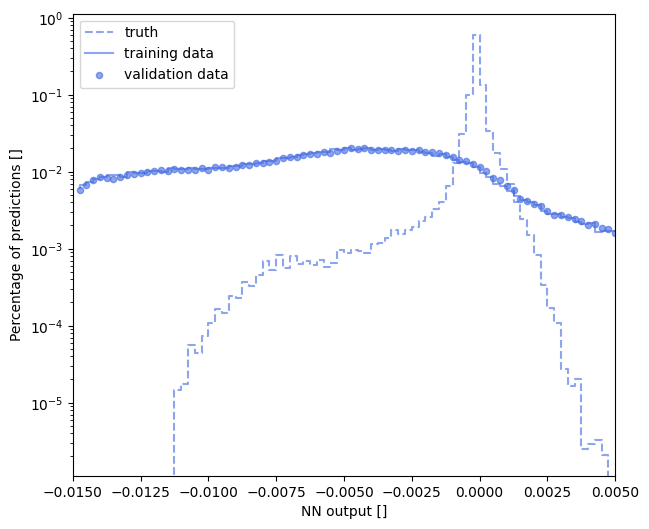

In [92]:
BINS = 80

coeff_index = 1

histograms_1 = generate_histograms(train_sets[0], predictions_train[0], val_sets[0], predictions_val[0], BINS, bounds=(-1.5e-2,5e-3))
histograms_2 = generate_histograms(train_sets[1], predictions_train[1], val_sets[1], predictions_val[1], BINS, bounds=(-1e-3,1.5e-3))
histograms_3 = generate_histograms(train_sets[2], predictions_train[2], val_sets[2], predictions_val[2], BINS, bounds=(-2e-5,1e-6))
histograms_4 = generate_histograms(train_sets[3], predictions_train[3], val_sets[3], predictions_val[3], BINS, bounds=(-5e-7,5e-6))

plot_histograms(histograms_1, color='royalblue', xlim=(-1.5e-2,5e-3))

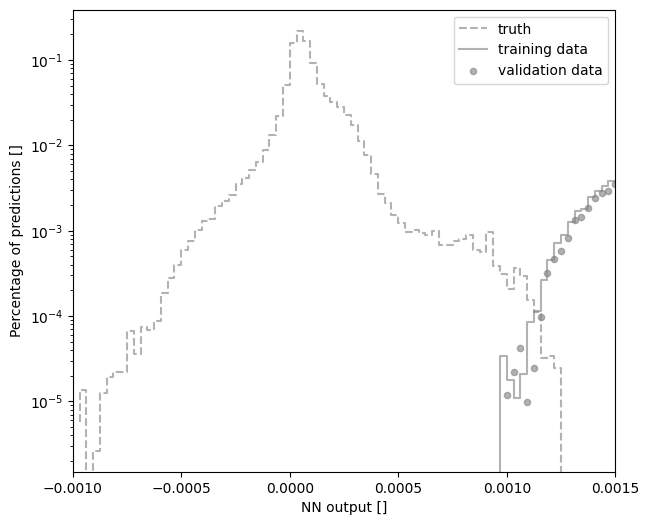

In [93]:
BINS=100

bounds = [-5,4]

h_calibration_train = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name=u'$log(r)$'),
    hist.axis.Regular(BINS, *bounds, name=u'$log(\hat{r})$')
)

h_calibration_train.fill(np.log(targets_train/(1-targets_train)), np.log(predictions_train/(1-predictions_train)))

h_calibration_val = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name=u'$log(r)$'),
    hist.axis.Regular(BINS, *bounds, name=u'$log(\hat{r})$')
)

h_calibration_val.fill(np.log(targets_val/(1-targets_val)), np.log(predictions_val/(1-predictions_val)))

cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,5))

h_calibration_train.plot2d(ax=ax1, cmap=cmap, cbar=False, norm=LogNorm())
ax1.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')

ax1.set_title('training data')

h_calibration_val.plot2d(ax=ax2, cmap=cmap, norm=LogNorm())
ax2.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')

ax2.set_title('validation data')

plt.show()

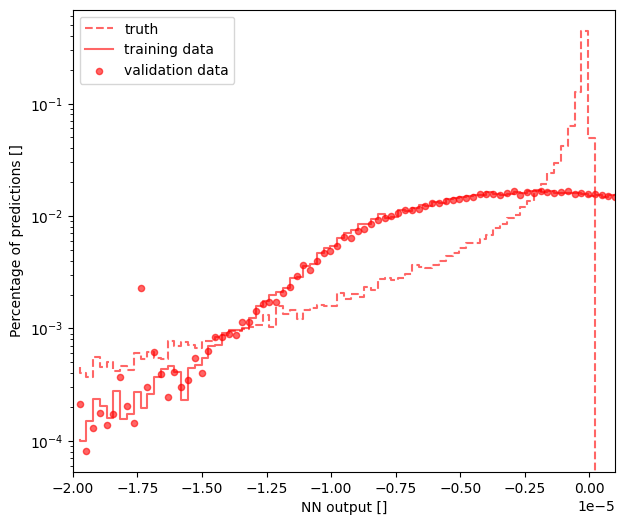

In [94]:
metrics = pd.read_csv(os.path.join(OUTPUT_DIR, LIGHTNING_DIR, 'metrics.csv'))

epochs = np.unique(metrics['epoch'].to_numpy())
train_loss = metrics['train_loss'].dropna().to_numpy()
val_loss = metrics['val_loss'].dropna().to_numpy()

plt.plot(epochs, train_loss, color='royalblue', label='training')
plt.plot(epochs, val_loss, color='red', label='validation')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()